<a href="https://colab.research.google.com/github/atharvapalav2005-wq/CSL701-CE-33_Machine-Learning-Lab/blob/main/ML_Experiment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Atharva Parag Palav Roll No: CE-33


# Machine Learning Experiment Number 3

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files


## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [10]:
uploaded = files.upload()
df = pd.read_csv("cardekho_dataset.csv")
df.head()

Saving cardekho_dataset.csv to cardekho_dataset (1).csv


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [29]:
# Display number of rows and columns
rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 15411
Number of columns: 15


In [30]:
# Numerical attributes
numerical_attributes = df.select_dtypes(include=np.number).columns.tolist()

# Categorical attributes
categorical_attributes = df.select_dtypes(include="object").columns.tolist()

print("Numerical attributes:")
print(numerical_attributes)

print("\nCategorical attributes:")
print(categorical_attributes)

# Target variable
y = df["selling_price"]

# Input features
X = df.drop("selling_price", axis=1)

print("Target variable:", y.name)
print("Feature columns:")
print(X.columns.tolist())

Numerical attributes:
['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price', 'Car_Age']

Categorical attributes:
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']
Target variable: selling_price
Feature columns:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'Car_Age']


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [59]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)


if df.isnull().sum().sum() > 0:
    print("Missing values found. Removing incomplete records...")


    df = df.dropna().reset_index(drop=True)
else:
    print("No missing values found.")

# Verify that no missing values remain
print("\nMissing values after preprocessing:")
print(df.isnull().sum())

# Check total number of missing values
total_missing = df.isnull().sum().sum()

print("\nTotal missing values:", total_missing)

if total_missing == 0:
    print("Dataset contains no missing values.")
else:
    print("Missing values are still present.")

# Separate features and target variable again
X = df.drop("selling_price", axis=1)
y = df["selling_price"]

print("\nFinal dataset shape:", df.shape)
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("dropna ()  method  is used to remove rows having missing values")



Missing values in each column:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
Car_Age              0
dtype: int64
No missing values found.

Missing values after preprocessing:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
Car_Age              0
dtype: int64

Total missing values: 0
Dataset contains no missing values.

Final dataset shape: (15411, 15)
Features shape: (15411, 14)
Target shape: (15411,)
dropna ()  method  is used to remove rows hav

## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [60]:

print("Available Attributes:")
print(df.columns.tolist())

print("\nAttribute Data Types:")
print(df.dtypes)


# 2. Separate the target variable
y = df["selling_price"]

# Create predictor variables by removing the target
X = df.drop("selling_price", axis=1)


# 3. Identify categorical attributes automatically
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

print("\nCategorical Attributes:")
print(categorical_columns)


# 4. Convert categorical attributes into numerical values
#    car_name is retained and converted using one-hot encoding.
X = pd.get_dummies(X, drop_first=True, dtype=int)


# 5. Convert all predictor variables and target to float
X = X.astype(float)
y = y.astype(float)


# 6. Display the prepared predictor matrix and target vector
print("\nPredictor Matrix X:")
display(X.head())

print("\nTarget Vector y:")
display(y.head())


# 7. Display the dimensions
print("\nNumber of observations:", X.shape[0])
print("Number of predictor features:", X.shape[1])
print("X shape:", X.shape)
print("y shape:", y.shape)


# 8. Record the final list of features
print("\nFinal Features Selected for the Model:")

for i, feature in enumerate(X.columns, start=1):
    print(i, ":", feature)

print("\nTarget Variable: selling_price")




Available Attributes:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price', 'Car_Age']

Attribute Data Types:
Unnamed: 0             int64
car_name              object
brand                 object
model                 object
vehicle_age            int64
km_driven              int64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
Car_Age                int64
dtype: object

Categorical Attributes:
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

Predictor Matrix X:


,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,Car_Age,car_name_Audi A6,car_name_Audi A8,...,model_i10,model_i20,model_redi-GO,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,0.0,9.0,120000.0,19.70,796.0,46.30,5.0,9.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,1.0,5.0,20000.0,18.90,1197.0,82.00,5.0,5.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
2,2.0,11.0,60000.0,17.00,1197.0,80.00,5.0,11.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
3,3.0,9.0,37000.0,20.92,998.0,67.10,5.0,9.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
4,4.0,6.0,30000.0,22.77,1498.0,98.59,5.0,6.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0



Target Vector y:


,selling_price
0,120000.0
1,550000.0
2,215000.0
3,226000.0
4,570000.0



Number of observations: 15411
Number of predictor features: 285
X shape: (15411, 285)
y shape: (15411,)

Final Features Selected for the Model:
1 : Unnamed: 0
2 : vehicle_age
3 : km_driven
4 : mileage
5 : engine
6 : max_power
7 : seats
8 : Car_Age
9 : car_name_Audi A6
10 : car_name_Audi A8
11 : car_name_Audi Q7
12 : car_name_BMW 3
13 : car_name_BMW 5
14 : car_name_BMW 6
15 : car_name_BMW 7
16 : car_name_BMW X1
17 : car_name_BMW X3
18 : car_name_BMW X4
19 : car_name_BMW X5
20 : car_name_BMW Z4
21 : car_name_Bentley Continental
22 : car_name_Datsun GO
23 : car_name_Datsun RediGO
24 : car_name_Datsun redi-GO
25 : car_name_Ferrari GTC4Lusso
26 : car_name_Force Gurkha
27 : car_name_Ford Aspire
28 : car_name_Ford Ecosport
29 : car_name_Ford Endeavour
30 : car_name_Ford Figo
31 : car_name_Ford Freestyle
32 : car_name_Honda Amaze
33 : car_name_Honda CR
34 : car_name_Honda CR-V
35 : car_name_Honda City
36 : car_name_Honda Civic
37 : car_name_Honda Jazz
38 : car_name_Honda WR-V
39 : car_name_Hy

## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [61]:
# Identify categorical variables
categorical_columns = ['fuel_type', 'seller_type', 'transmission_type']

print("Categorical Variables:")
print(categorical_columns)

# Display unique categories
for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].unique())

# Convert categorical variables into dummy/indicator variables
df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

# Verify that all predictors are numerical
print("\nData types after encoding:")
print(df_encoded.dtypes)

# Check whether any categorical/object columns remain
categorical_after_encoding = df_encoded.select_dtypes(
    include=['object']
).columns.tolist()

print("\nCategorical columns remaining:")
print(categorical_after_encoding)

if len(categorical_after_encoding) == 0:
    print("All predictors are numerical after encoding.")

# Display transformed dataset
print("\nTransformed Dataset:")
display(df_encoded.head())

Categorical Variables:
['fuel_type', 'seller_type', 'transmission_type']

fuel_type:
['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']

seller_type:
['Individual' 'Dealer' 'Trustmark Dealer']

transmission_type:
['Manual' 'Automatic']

Data types after encoding:
Unnamed: 0                        int64
car_name                         object
brand                            object
model                            object
vehicle_age                       int64
km_driven                         int64
mileage                         float64
engine                            int64
max_power                       float64
seats                             int64
selling_price                     int64
Car_Age                           int64
fuel_type_Diesel                  int64
fuel_type_Electric                int64
fuel_type_LPG                     int64
fuel_type_Petrol                  int64
seller_type_Individual            int64
seller_type_Trustmark Dealer      int64
transmission_type_Manual

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,Car_Age,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
0,0,Maruti Alto,Maruti,Alto,9,120000,19.70,796,46.30,5,120000,9,0,0,0,1,1,0,1
1,1,Hyundai Grand,Hyundai,Grand,5,20000,18.90,1197,82.00,5,550000,5,0,0,0,1,1,0,1
2,2,Hyundai i20,Hyundai,i20,11,60000,17.00,1197,80.00,5,215000,11,0,0,0,1,1,0,1
3,3,Maruti Alto,Maruti,Alto,9,37000,20.92,998,67.10,5,226000,9,0,0,0,1,1,0,1
4,4,Ford Ecosport,Ford,Ecosport,6,30000,22.77,1498,98.59,5,570000,6,1,0,0,0,0,0,1


## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [62]:
# Task 6: Perform Feature Engineering

# Create Car_Age using the existing vehicle_age column
df["Car_Age"] = df["vehicle_age"]

# Display several values
print("Car Age values:")
display(df[["vehicle_age", "Car_Age"]].head(10))

# Verify that the ages are reasonable
print("\nCar Age Statistics:")
print(df["Car_Age"].describe())

print("\nMinimum Car Age:", df["Car_Age"].min())
print("Maximum Car Age:", df["Car_Age"].max())

# Decision about the original Year feature
print("\nDecision:")
print("The original Year feature is not retained because the dataset")
print("does not contain a Year column. The existing vehicle_age column")
print("already provides the age of each car.")

Car Age values:


,vehicle_age,Car_Age
0,9,9
1,5,5
2,11,11
3,9,9
4,6,6
5,8,8
6,8,8
7,3,3
8,2,2
9,4,4



Car Age Statistics:
count    15411.000000
mean         6.036338
std          3.013291
min          0.000000
25%          4.000000
50%          6.000000
75%          8.000000
max         29.000000
Name: Car_Age, dtype: float64

Minimum Car Age: 0
Maximum Car Age: 29

Decision:
The original Year feature is not retained because the dataset
does not contain a Year column. The existing vehicle_age column
already provides the age of each car.


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

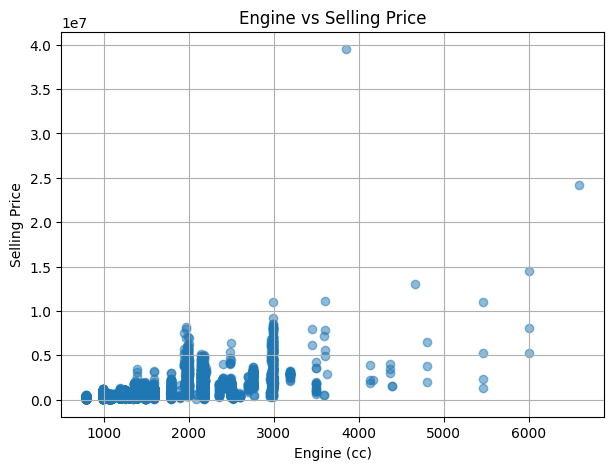

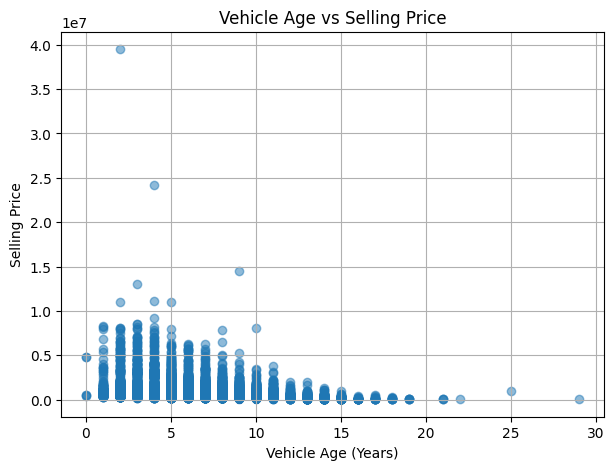

In [63]:
# Task 7: Exploratory Data Analysis

# Convert required columns to numeric
df["engine"] = pd.to_numeric(df["engine"], errors="coerce")
df["selling_price"] = pd.to_numeric(df["selling_price"], errors="coerce")
df["vehicle_age"] = pd.to_numeric(df["vehicle_age"], errors="coerce")

# Remove rows with missing values in required columns
plot_df = df.dropna(
    subset=["engine", "selling_price", "vehicle_age"]
)


# Scatter Plot 1: Engine vs Selling Price
plt.figure(figsize=(7, 5))

plt.scatter(
    plot_df["engine"],
    plot_df["selling_price"],
    alpha=0.5
)

plt.xlabel("Engine (cc)")
plt.ylabel("Selling Price")
plt.title("Engine vs Selling Price")
plt.grid(True)
plt.show()


# Scatter Plot 2: Vehicle Age vs Selling Price
plt.figure(figsize=(7, 5))

plt.scatter(
    plot_df["vehicle_age"],
    plot_df["selling_price"],
    alpha=0.5
)

plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Selling Price")
plt.title("Vehicle Age vs Selling Price")
plt.grid(True)
plt.show()


## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [64]:
# Convert X and y to NumPy arrays
X_array = X.to_numpy(dtype=float)
y_array = y.to_numpy(dtype=float)



np.random.seed(42)

# Generate shuffled indices
indices = np.random.permutation(len(X_array))

# 80% training, 20% testing
train_size = int(0.80 * len(X_array))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

# Create training and testing datasets
Xtrain = X_array[train_indices]
Xtest = X_array[test_indices]

ytrain = y_array[train_indices]
ytest = y_array[test_indices]

print("Training observations:", Xtrain.shape[0])
print("Testing observations:", Xtest.shape[0])

print("Xtrain shape:", Xtrain.shape)
print("Xtest shape:", Xtest.shape)
print("ytrain shape:", ytrain.shape)
print("ytest shape:", ytest.shape)



# Numerical columns in the original dataset
numeric_columns = [
    'vehicle_age',
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'seats'
]

# Find their column positions in X
numeric_indices = [
    X.columns.get_loc(col)
    for col in numeric_columns
    if col in X.columns
]

print("\nNumerical feature indices:")
print(numeric_indices)

# Calculate mean and standard deviation
# USING TRAINING DATA ONLY
train_mean = Xtrain[:, numeric_indices].mean(axis=0)
train_std = Xtrain[:, numeric_indices].std(axis=0)

# Prevent division by zero
train_std[train_std == 0] = 1

# Standardize training data
Xtrain[:, numeric_indices] = (
    Xtrain[:, numeric_indices] - train_mean
) / train_std

# Standardize test data using the SAME
# training mean and standard deviation
Xtest[:, numeric_indices] = (
    Xtest[:, numeric_indices] - train_mean
) / train_std

print("\nStandardization completed.")

print("\nTraining means:")
print(train_mean)

print("\nTraining standard deviations:")
print(train_std)

Training observations: 12328
Testing observations: 3083
Xtrain shape: (12328, 285)
Xtest shape: (3083, 285)
ytrain shape: (12328,)
ytest shape: (3083,)

Numerical feature indices:
[1, 2, 3, 4, 5, 6]

Standardization completed.

Training means:
[6.03244646e+00 5.56928196e+04 1.96915518e+01 1.48503739e+03
 1.00516747e+02 5.32624919e+00]

Training standard deviations:
[3.01874714e+00 5.44709544e+04 4.17263296e+00 5.18275963e+02
 4.27439546e+01 8.09570519e-01]


## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [65]:


# Convert X and y to NumPy arrays
X_array = X.to_numpy(dtype=float)
y_array = y.to_numpy(dtype=float)

# Set fixed random seed for reproducibility
np.random.seed(42)

# Generate random indices
indices = np.random.permutation(len(X_array))

# Calculate 80% training size
train_size = int(0.80 * len(X_array))

# Split indices
train_indices = indices[:train_size]
test_indices = indices[train_size:]

# Create training and testing sets
Xtrain = X_array[train_indices]
Xtest = X_array[test_indices]

ytrain = y_array[train_indices]
ytest = y_array[test_indices]

# Display number of observations
print("Total observations:", len(X_array))
print("Training observations:", len(Xtrain))
print("Testing observations:", len(Xtest))

# Display shapes
print("\nXtrain shape:", Xtrain.shape)
print("Xtest shape:", Xtest.shape)
print("ytrain shape:", ytrain.shape)
print("ytest shape:", ytest.shape)

Total observations: 15411
Training observations: 12328
Testing observations: 3083

Xtrain shape: (12328, 285)
Xtest shape: (3083, 285)
ytrain shape: (12328,)
ytest shape: (3083,)


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [66]:
print("Xtrain:", Xtrain.shape)
print("ytrain:", ytrain.shape)
print("Xtest:", Xtest.shape)
print("ytest:", ytest.shape)

print("\nNumber of predictor columns:", Xtrain.shape[1])

Xtrain: (12328, 285)
ytrain: (12328,)
Xtest: (3083, 285)
ytest: (3083,)

Number of predictor columns: 285


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [67]:
# Add a leading column of ones
Xtrain_bias = np.column_stack(
    (np.ones(Xtrain.shape[0]), Xtrain)
)

Xtest_bias = np.column_stack(
    (np.ones(Xtest.shape[0]), Xtest)
)

print("Xtrain with bias:", Xtrain_bias.shape)
print("Xtest with bias:", Xtest_bias.shape)

print("\nFirst row of Xtrain with bias:")
print(Xtrain_bias[0])

Xtrain with bias: (12328, 286)
Xtest with bias: (3083, 286)

First row of Xtrain with bias:
[1.000e+00 4.259e+03 1.200e+01 7.300e+04 2.036e+01 1.197e+03 7.890e+01
 5.000e+00 1.200e+01 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 1.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000

## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [68]:
def ordinary_least_squares(X, y):
    # Calculate X^T X
    XTX = X.T @ X

    # Calculate X^T y
    XTy = X.T @ y

    # Calculate regression coefficients
    # Pseudoinverse handles singular matrices
    beta = np.linalg.pinv(XTX) @ XTy

    return beta


# Train the model
beta = ordinary_least_squares(Xtrain_bias, ytrain)

print("Coefficient vector shape:", beta.shape)

print("\nRegression coefficients:")
print(beta)

Coefficient vector shape: (286,)

Regression coefficients:
[ 2.84385111e+06  3.33799027e-01 -2.02693065e+05 -4.93363936e-01
 -2.39381496e+03 -1.58458114e+02  5.85805490e+03 -3.97205233e+04
  1.23063014e+05 -4.10844324e+05  2.18957498e+05 -1.12155943e+05
 -1.27709395e+06 -1.64068079e+05  6.74043549e+05  2.14651441e+05
 -6.00759478e+05 -3.34593056e+05  9.40815176e+05  4.21739455e+05
  3.62700084e+05  3.29676546e+06 -3.53370629e+05 -4.51211278e+05
 -4.36114292e+05  1.13467027e+07 -5.13569519e+05 -4.10475258e+05
 -3.31547951e+05  2.95342830e+05 -3.26933232e+05 -4.10540296e+05
 -3.33691062e+05 -6.15056837e+04  6.87576126e+04 -2.34612464e+05
 -1.79806183e+05 -2.95916809e+05 -2.62032689e+05 -1.58269400e+05
 -1.11505941e+05 -1.00993606e+05 -2.59659084e+05 -1.68766635e+05
  1.16754866e+05 -2.15725153e+05 -2.05665016e+05 -1.46892806e+05
 -1.93317759e+05  1.42615112e-07 -4.53755273e+05 -8.75697570e+04
  8.24761178e+05 -1.45517083e+05 -4.14876044e+05 -7.72323564e+05
  8.55676672e+05  1.40431316e+0

## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [69]:
XTX = Xtrain_bias.T @ Xtrain_bias

determinant = np.linalg.det(XTX)

print("Determinant of XTX:", determinant)

if np.isclose(determinant, 0):
    print("XTX is singular or nearly singular.")
    print("Possible multicollinearity or redundant features exists.")
else:
    print("XTX is not singular.")

Determinant of XTX: 0.0
XTX is singular or nearly singular.
Possible multicollinearity or redundant features exists.


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [70]:
feature_names = ["Intercept"] + X.columns.tolist()

print("Regression Coefficients:\n")

for feature, coefficient in zip(feature_names, beta):
    print(f"{feature}: {coefficient}")

Regression Coefficients:

Intercept: 2843851.107233897
Unnamed: 0: 0.333799027341439
vehicle_age: -202693.06532033917
km_driven: -0.4933639364636919
mileage: -2393.8149556351127
engine: -158.4581142374209
max_power: 5858.054898201248
seats: -39720.52326778835
Car_Age: 123063.01411721512
car_name_Audi A6: -410844.32438146777
car_name_Audi A8: 218957.49834426073
car_name_Audi Q7: -112155.94266298274
car_name_BMW 3: -1277093.9492797488
car_name_BMW 5: -164068.07907377192
car_name_BMW 6: 674043.5493460204
car_name_BMW 7: 214651.44080291005
car_name_BMW X1: -600759.4783150938
car_name_BMW X3: -334593.0562888172
car_name_BMW X4: 940815.176023523
car_name_BMW X5: 421739.454745046
car_name_BMW Z4: 362700.0839907066
car_name_Bentley Continental: 3296765.4552692384
car_name_Datsun GO: -353370.6292839057
car_name_Datsun RediGO: -451211.27832423337
car_name_Datsun redi-GO: -436114.2918766304
car_name_Ferrari GTC4Lusso: 11346702.711337294
car_name_Force Gurkha: -513569.5185290158
car_name_Ford Aspi

## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [71]:
coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": beta
})

coefficient_table["Sign"] = np.where(
    coefficient_table["Coefficient"] >= 0,
    "Positive",
    "Negative"
)

coefficient_table["Absolute_Influence"] = (
    coefficient_table["Coefficient"].abs()
)

coefficient_table = coefficient_table.sort_values(
    "Absolute_Influence",
    ascending=False
)

display(coefficient_table)

,Feature,Coefficient,Sign,Absolute_Influence
209,model_GTC4Lusso,1.134670e+07,Positive,1.134670e+07
132,brand_Ferrari,1.134670e+07,Positive,1.134670e+07
25,car_name_Ferrari GTC4Lusso,1.134670e+07,Positive,1.134670e+07
21,car_name_Bentley Continental,3.296765e+06,Positive,3.296765e+06
130,brand_Bentley,3.296765e+06,Positive,3.296765e+06
...,...,...,...,...
107,car_name_Rolls-Royce Ghost,-2.754743e-09,Negative,2.754743e-09
137,brand_ISUZU,0.000000e+00,Positive,0.000000e+00
154,brand_Rolls-Royce,0.000000e+00,Positive,0.000000e+00
211,model_Ghost,0.000000e+00,Positive,0.000000e+00


## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [72]:
y_pred = Xtest_bias @ beta

comparison = pd.DataFrame({
    "Actual Selling Price": ytest,
    "Predicted Selling Price": y_pred
})

print("Sample actual vs predicted values:")
display(comparison.head(10))

Sample actual vs predicted values:


,Actual Selling Price,Predicted Selling Price
0,4450000.0,2.247722e+06
1,1290000.0,1.430849e+06
2,485000.0,4.452386e+05
3,400000.0,4.306872e+05
4,800000.0,8.006224e+05
5,150000.0,-2.557626e+05
6,650000.0,7.048316e+05
7,325000.0,-3.677484e+04
8,300000.0,3.354132e+05
9,925000.0,1.096149e+06


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [73]:
residuals = ytest - y_pred

RSS = np.sum(residuals ** 2)

print("Residual Sum of Squares (RSS):", RSS)

Residual Sum of Squares (RSS): 975217279159169.8


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [74]:
TSS = np.sum((ytest - np.mean(ytest)) ** 2)

R2 = 1 - (RSS / TSS)

print("Total Sum of Squares (TSS):", TSS)
print("R²:", R2)

Total Sum of Squares (TSS): 2407385049859876.5
R²: 0.5949059834794883


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


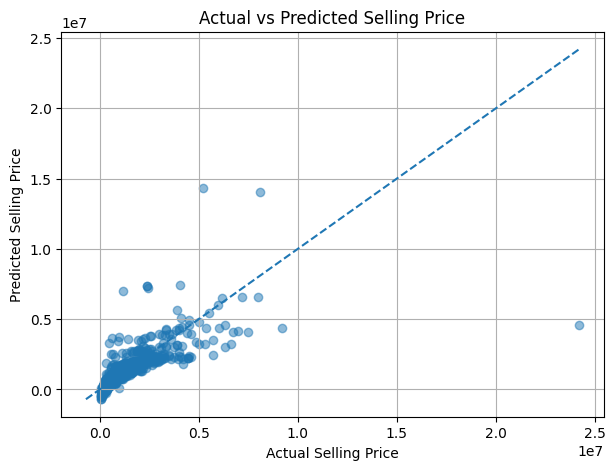

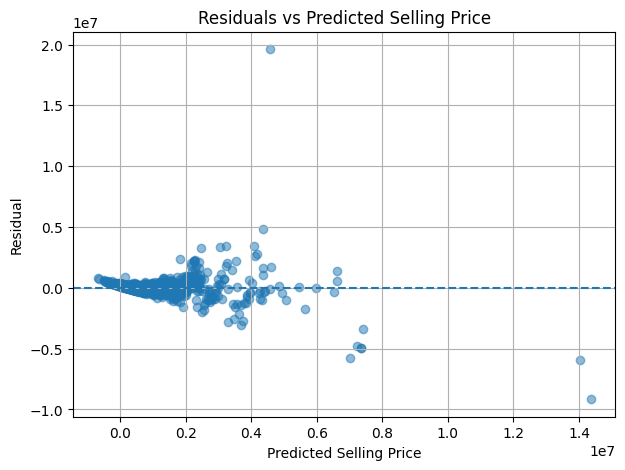

10 Observations with the Largest Prediction Errors:


,Actual Selling Price,Predicted Selling Price,Residual,Absolute Error
0,24200000.0,4.583082e+06,1.961692e+07,1.961692e+07
1,5200000.0,1.435862e+07,-9.158625e+06,9.158625e+06
2,8100000.0,1.403623e+07,-5.936227e+06,5.936227e+06
3,1200000.0,7.001274e+06,-5.801274e+06,5.801274e+06
4,2400000.0,7.351234e+06,-4.951234e+06,4.951234e+06
5,2400000.0,7.345480e+06,-4.945480e+06,4.945480e+06
6,9200000.0,4.364920e+06,4.835080e+06,4.835080e+06
7,2450000.0,7.221040e+06,-4.771040e+06,4.771040e+06
8,6645000.0,3.222053e+06,3.422947e+06,3.422947e+06
9,7500000.0,4.094687e+06,3.405313e+06,3.405313e+06


In [75]:




# Calculate residuals
residuals = ytest - y_pred


# 1. Actual vs Predicted Selling Price
plt.figure(figsize=(7, 5))

plt.scatter(
    ytest,
    y_pred,
    alpha=0.5
)

# Perfect prediction reference line
min_value = min(ytest.min(), y_pred.min())
max_value = max(ytest.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.grid(True)
plt.show()


# 2. Residual Plot
plt.figure(figsize=(7, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

# Zero-error reference line
plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Selling Price")
plt.grid(True)
plt.show()


# 3. Identify observations with large prediction errors

absolute_errors = np.abs(residuals)

large_error_indices = np.argsort(
    absolute_errors
)[-10:][::-1]

large_errors = pd.DataFrame({
    "Actual Selling Price": ytest[large_error_indices],
    "Predicted Selling Price": y_pred[large_error_indices],
    "Residual": residuals[large_error_indices],
    "Absolute Error": absolute_errors[large_error_indices]
})

print("10 Observations with the Largest Prediction Errors:")
display(large_errors)





### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


In [76]:
print("=" * 70)
print("MULTIPLE LINEAR REGRESSION - CARDEKHO USED CAR DATASET")
print("=" * 70)

print("\nDataset Information")
print("-------------------")

print("Total observations:", len(X))
print("Training observations:", len(Xtrain))
print("Testing observations:", len(Xtest))

print("\nNumber of predictors:",
      len(feature_names))

print("\nModel Performance")
print("-----------------")

print(f"RSS : {RSS:.4f}")
print(f"TSS : {TSS:.4f}")
print(f"R²  : {R2:.4f}")
print(f"R²% : {R2 * 100:.2f}%")

MULTIPLE LINEAR REGRESSION - CARDEKHO USED CAR DATASET

Dataset Information
-------------------
Total observations: 15411
Training observations: 12328
Testing observations: 3083

Number of predictors: 286

Model Performance
-----------------
RSS : 975217279159169.7500
TSS : 2407385049859876.5000
R²  : 0.5949
R²% : 59.49%


The most influential features are the ones with the largest absolute regression coefficients. Positive coefficients indicate that the feature increases the predicted selling price, while negative coefficients indicate a decrease, keeping other features constant.

Advantages of Multiple Linear Regression:

1.Simple and relatively easy to implement and interpret.

2.Regression coefficients show the direction and relative effect of individual features.

3.Can handle multiple numerical and categorical predictors after suitable preprocessing.

Limitations of Multiple Linear Regression:

1.Assumes a linear relationship between predictors and selling price.

2.May not capture complex nonlinear relationships between vehicle characteristics and price.

3.Highly correlated or redundant features can cause multicollinearity, which can make the OLS matrix singular or make coefficient estimates unstable.

### Conclusion
Conclude the experiment by stating whether the Multiple Linear Regression model implemented using the OLS normal equation was able to predict used-car selling prices effectively. The conclusion should include the obtained RSS and R² values, observations regarding important features, the effect of preprocessing and feature engineering, and the limitations of using a linear regression model for real-world used-car price prediction.